In [ ]:
import pandas as pd
data=pd.read_csv("/content/AmazonCleanedData_Process1.csv")
df=pd.DataFrame(data)
df.head()


,product_id,product_name,discounted_price,actual_price,discount_percentage,rating,rating_count,Root (Department),Category,Sub_category,Sub-sub_category,Product_type
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,399.0,1099.0,64,4.2,24269.0,Computers & Accessories,Accessories & Peripherals,Cables & Accessories,Cables,USBCables
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,199.0,349.0,43,4.0,43994.0,Computers & Accessories,Accessories & Peripherals,Cables & Accessories,Cables,USBCables
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,199.0,1899.0,90,3.9,7928.0,Computers & Accessories,Accessories & Peripherals,Cables & Accessories,Cables,USBCables
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,329.0,699.0,53,4.2,94363.0,Computers & Accessories,Accessories & Peripherals,Cables & Accessories,Cables,USBCables
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,154.0,399.0,61,4.2,16905.0,Computers & Accessories,Accessories & Peripherals,Cables & Accessories,Cables,USBCables


In [ ]:
df.isnull().sum()

,0
product_id,0
product_name,0
discounted_price,0
actual_price,0
discount_percentage,0
rating,0
rating_count,0
Root (Department),0
Category,0
Sub_category,0


In [ ]:
df.describe()

,discounted_price,actual_price,discount_percentage,rating,rating_count
count,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000
mean,3135.120925,5461.596491,47.716929,4.096669,18277.867032
std,6956.725119,10893.774335,21.634482,0.291709,42788.295174
min,39.000000,39.000000,0.000000,2.000000,2.000000
25%,325.000000,812.500000,32.000000,4.000000,1186.000000
50%,799.000000,1690.000000,50.000000,4.100000,5179.000000
75%,1999.000000,4331.480000,63.000000,4.300000,17271.500000
max,77990.000000,139900.000000,94.000000,5.000000,426973.000000


In [ ]:
(df['discounted_price'] > df['actual_price']).sum()


np.int64(0)

Descriptive Statistics (Univariate Analsysis)

1. Distribution Analysis

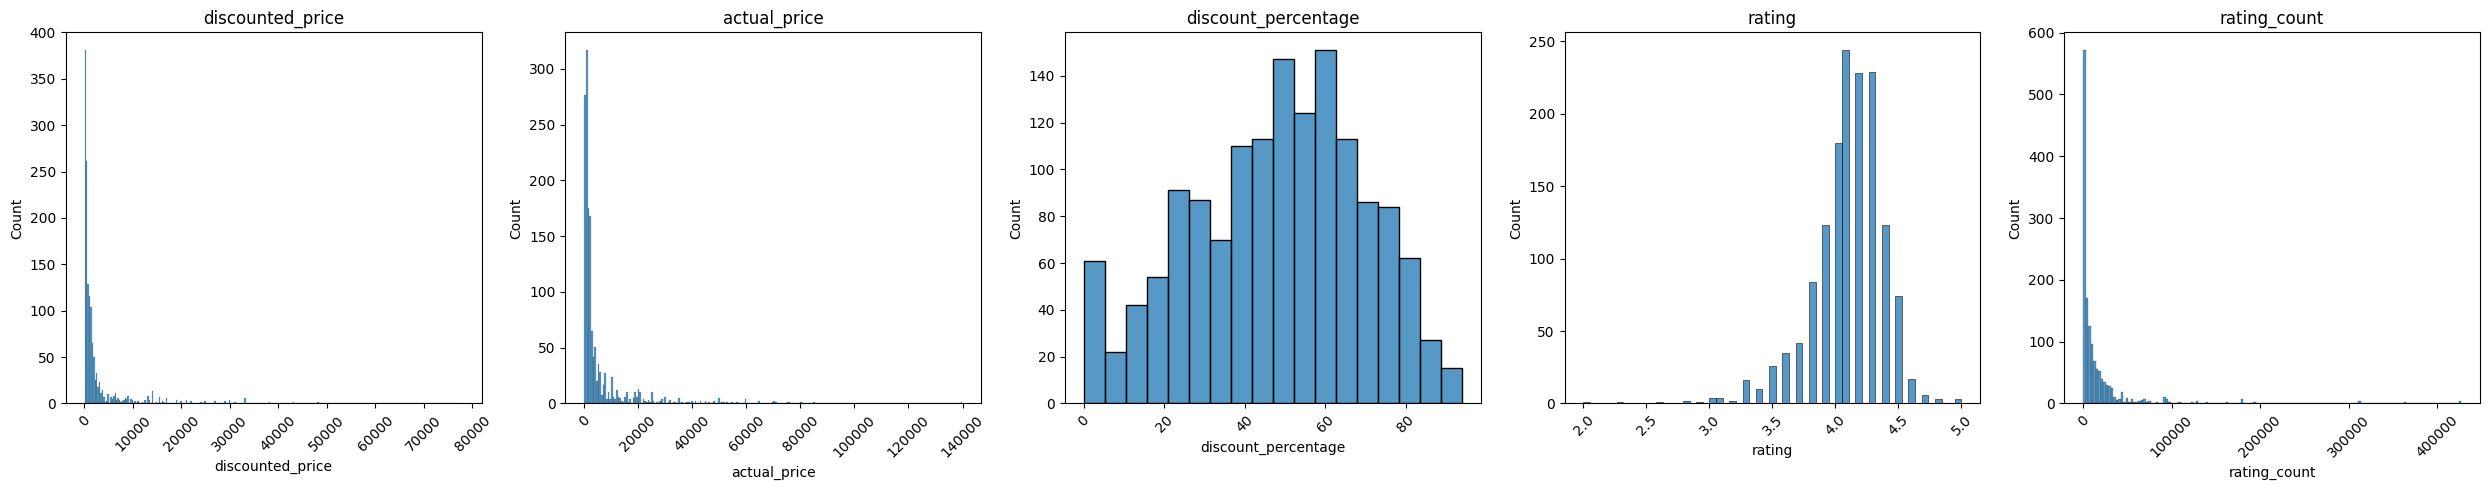

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for i, col in enumerate(num_cols):
    sns.histplot(df[col], bins='auto', ax=axes[i])
    axes[i].set_title(f'{col}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

2. Outliers detection

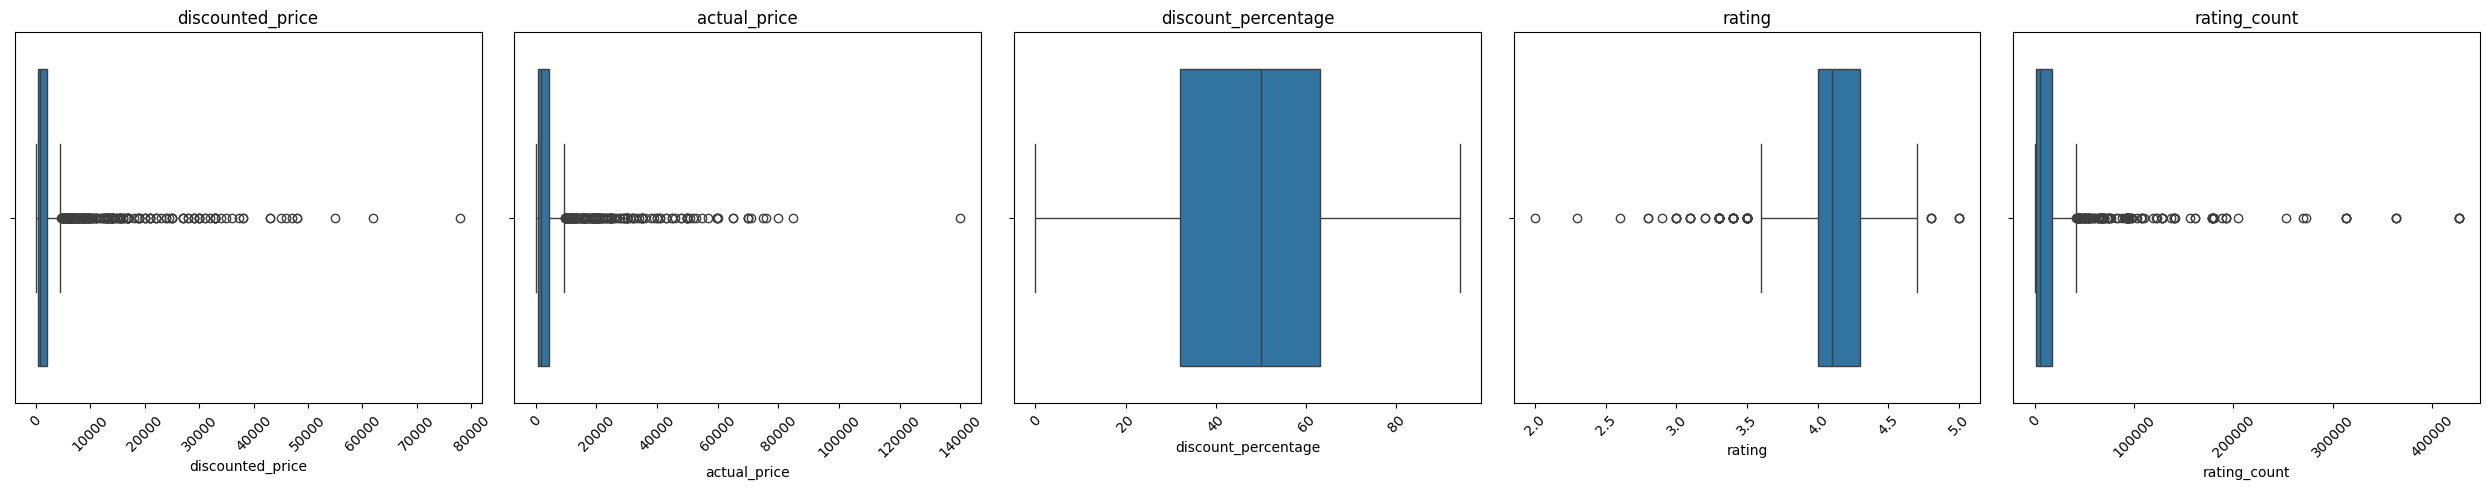

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

3. Detect the outliers using IQR

In [ ]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)  # First quartile
    Q3 = data[column].quantile(0.75)  # Third quartile
    IQR = Q3 - Q1  # Interquartile range
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

#Check outliers for each numeric column
for col in num_cols:
    outliers = detect_outliers_iqr(df, col)
    print(f"Outliers in {col}: {len(outliers)} rows")

Outliers in discounted_price: 217 rows
Outliers in actual_price: 213 rows
Outliers in discount_percentage: 0 rows
Outliers in rating: 74 rows
Outliers in rating_count: 140 rows


4. Calculate the IQR

In [ ]:
def calculate_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    print(f"\nColumn: {column}")
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    calculate_iqr(df, col)


Column: discounted_price
Q1: 325.0
Q3: 1999.0
IQR: 1674.0

Column: actual_price
Q1: 812.5
Q3: 4331.48
IQR: 3518.9799999999996

Column: discount_percentage
Q1: 32.0
Q3: 63.0
IQR: 31.0

Column: rating
Q1: 4.0
Q3: 4.3
IQR: 0.2999999999999998

Column: rating_count
Q1: 1186.0
Q3: 17271.5
IQR: 16085.5
